In [92]:
# =============================================================================
# Atividade: Explainable AI com Dataset Titanic
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import shap

In [93]:
# =============================================================================
# 1. Coleta e carregamento dos dados
# =============================================================================
print("="*60)
print("1. CARREGAMENTO E INSPEÇÃO DOS DADOS")
print("="*60)

df = pd.read_csv('/content/titanic.csv')   # caminho no Colap
print("Primeiras 5 linhas:")
print(df.head())

print("\nInformações gerais:")
print(df.info())

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nDistribuição da variável alvo (Survived):")
print(df['Survived'].value_counts())
print(f"Porcentagem de sobreviventes: {df['Survived'].mean()*100:.2f}%")

1. CARREGAMENTO E INSPEÇÃO DOS DADOS
Primeiras 5 linhas:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S 

In [94]:
# =============================================================================
# 2. Preparação dos dados
# =============================================================================
print("\n" + "="*60)
print("2. PRÉ-PROCESSAMENTO")
print("="*60)

# Selecionar features relevantes
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features].copy()
y = df['Survived'].copy()

# Tratar valores ausentes
X['Age'].fillna(X['Age'].median(), inplace=True)
X['Embarked'].fillna(X['Embarked'].mode()[0], inplace=True)

# Codificar variáveis categóricas
le_sex = LabelEncoder()
X['Sex'] = le_sex.fit_transform(X['Sex'])   # male=1, female=0

le_embarked = LabelEncoder()
X['Embarked'] = le_embarked.fit_transform(X['Embarked'])  # C=0, Q=1, S=2

print("Features após pré-processamento:")
print(X.head())
print("\nInformações:")
print(X.info())

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTamanho do treino: {X_train.shape[0]} amostras")
print(f"Tamanho do teste: {X_test.shape[0]} amostras")


2. PRÉ-PROCESSAMENTO
Features após pré-processamento:
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2

Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    int64  
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 48.9 KB
None

Tamanho do treino: 712 amostras
Tamanho do teste: 179 amostras


/tmp/ipykernel_352/3475278369.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(X['Age'].median(), inplace=True)
/tmp/ipykernel_352/3475278369.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [95]:
# =============================================================================
# 3. Treinamento do modelo
# =============================================================================
print("\n" + "="*60)
print("3. TREINAMENTO DO MODELO (Random Forest)")
print("="*60)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Modelo treinado com sucesso!")


3. TREINAMENTO DO MODELO (Random Forest)
Modelo treinado com sucesso!



4. AVALIAÇÃO DO MODELO
Acurácia: 0.8268

Relatório de Classificação:
                precision    recall  f1-score   support

Não Sobreviveu       0.84      0.89      0.86       110
    Sobreviveu       0.81      0.72      0.76        69

      accuracy                           0.83       179
     macro avg       0.82      0.81      0.81       179
  weighted avg       0.83      0.83      0.82       179


Matriz de Confusão:
[[98 12]
 [19 50]]


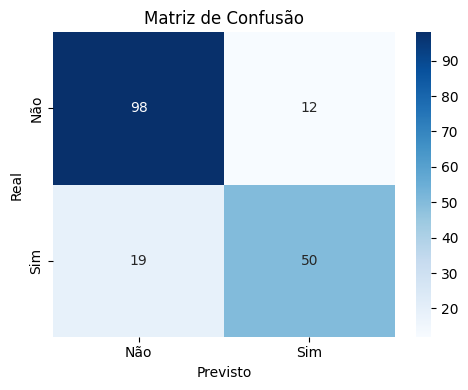

In [96]:
# =============================================================================
# 4. Validação do modelo
# =============================================================================
print("\n" + "="*60)
print("4. AVALIAÇÃO DO MODELO")
print("="*60)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.4f}")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Sobreviveu', 'Sobreviveu']))

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plotar matriz de confusão
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não', 'Sim'], yticklabels=['Não', 'Sim'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.tight_layout()
plt.show()


5. IMPORTÂNCIA DAS FEATURES
Importância das features:
 feature  importance
    Fare    0.270237
     Sex    0.260625
     Age    0.250389
  Pclass    0.092549
   SibSp    0.050297
   Parch    0.041084
Embarked    0.034820


/tmp/ipykernel_352/1710846019.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')


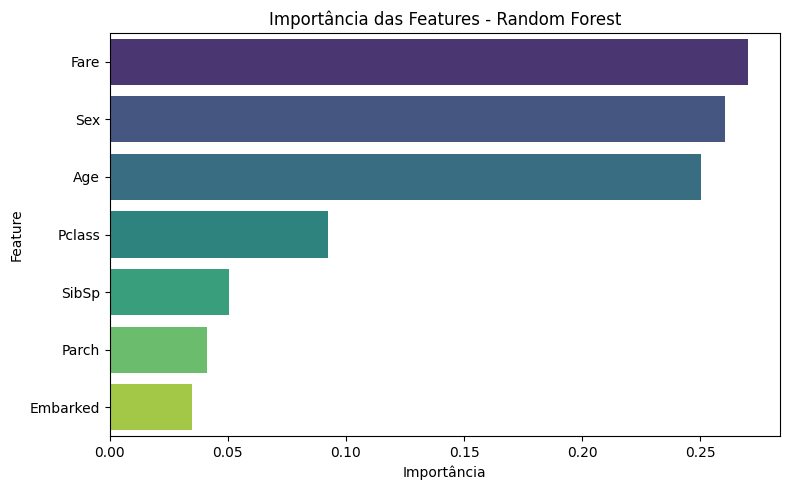


Análise: As features mais importantes são: Sex, Fare e Age.
Sex é a mais influente: mulheres tiveram maior chance de sobrevivência.
Fare (tarifa) reflete a classe social: passageiros mais ricos sobreviveram mais.
Age também é relevante: crianças tiveram prioridade nos botes.


In [97]:
# =============================================================================
# 5. Análise de Feature Importance
# =============================================================================
print("\n" + "="*60)
print("5. IMPORTÂNCIA DAS FEATURES")
print("="*60)

importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

print("Importância das features:")
print(feat_imp.to_string(index=False))

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.title('Importância das Features - Random Forest')
plt.tight_layout()
plt.show()

print("\nAnálise: As features mais importantes são: Sex, Fare e Age.")
print("Sex é a mais influente: mulheres tiveram maior chance de sobrevivência.")
print("Fare (tarifa) reflete a classe social: passageiros mais ricos sobreviveram mais.")
print("Age também é relevante: crianças tiveram prioridade nos botes.")


6. EXPLICABILIDADE COM SHAP
shap_values_class1.shape: (179, 7)
X_test_pt.shape: (179, 7)
X_test_pt dtypes: Classe             int64
Sexo               int64
Idade            float64
IrmaosConjuge      int64
PaisFilhos         int64
Tarifa           float64
Embarque           int64
dtype: object


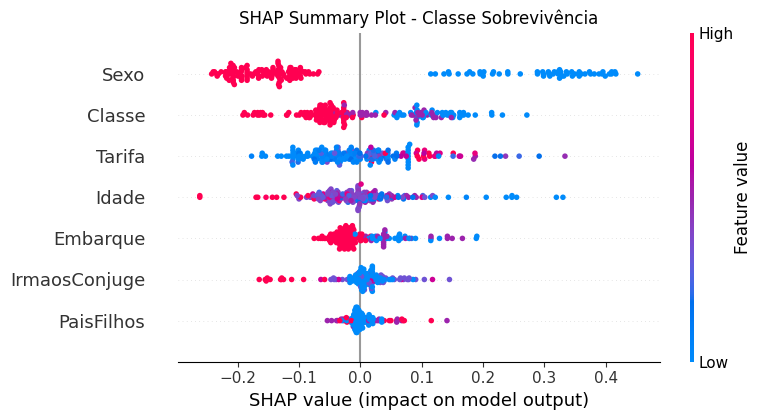


Interpretação do Summary Plot:
- No eixo X, valores positivos aumentam a probabilidade de sobrevivência.
- A cor representa o valor da feature (vermelho = alto, azul = baixo).
- Sexo: valores baixos (female) aumentam a sobrevivência (SHAP positivo).
- Tarifa: valores altos (vermelho) tendem a aumentar a sobrevivência.
- Idade: valores baixos (crianças) aumentam a sobrevivência; valores altos (idosos) reduzem.
- Classe: valores baixos (1ª classe) aumentam a sobrevivência.


In [98]:
 #=============================================================================
# 6. Explainable AI com SHAP
# =============================================================================
print("\n" + "="*60)
print("6. EXPLICABILIDADE COM SHAP")
print("="*60)

# Criar explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Criar um DataFrame com os dados de teste e nomes em português
X_test_pt = X_test.copy()
X_test_pt.columns = ['Classe', 'Sexo', 'Idade', 'IrmaosConjuge', 'PaisFilhos', 'Tarifa', 'Embarque']

# Para modelos de classificação binária, shap.TreeExplainer.shap_values pode retornar
# uma lista de arrays (shap_values[0] para classe 0, shap_values[1] para classe 1)
# ou um array 3D de forma (n_amostras, n_features, n_classes).
# Com base no erro anterior ('shap_values[1].shape: (7, 2)'),
# assume-se que 'shap_values' é um array 3D e 'shap_values[1]' estava selecionando a segunda amostra.
# Para plotar a classe de sobrevivência (classe 1) para todas as amostras:
shap_values_class1 = shap_values[:, :, 1] # Seleciona todas as amostras, todas as features, para a classe 1

# Verificar dimensões corrigidas
print("shap_values_class1.shape:", shap_values_class1.shape)
print("X_test_pt.shape:", X_test_pt.shape)
print("X_test_pt dtypes:", X_test_pt.dtypes)

# SHAP Summary Plot (para a classe 1 - sobrevivência)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_class1, X_test_pt.values,
                  feature_names=X_test_pt.columns.tolist(),
                  show=False)
plt.title('SHAP Summary Plot - Classe Sobrevivência')
plt.tight_layout()
plt.show()

print("\nInterpretação do Summary Plot:")
print("- No eixo X, valores positivos aumentam a probabilidade de sobrevivência.")
print("- A cor representa o valor da feature (vermelho = alto, azul = baixo).")
print("- Sexo: valores baixos (female) aumentam a sobrevivência (SHAP positivo).")
print("- Tarifa: valores altos (vermelho) tendem a aumentar a sobrevivência.")
print("- Idade: valores baixos (crianças) aumentam a sobrevivência; valores altos (idosos) reduzem.")
print("- Classe: valores baixos (1ª classe) aumentam a sobrevivência.")


7. EXPLICAÇÃO INDIVIDUAL

Amostra índice 5 no conjunto de teste:
Valores das features:
           559
Pclass     3.0
Sex        0.0
Age       36.0
SibSp      1.0
Parch      0.0
Fare      17.4
Embarked   2.0

Valor real: Sobreviveu
Previsão do modelo: Não Sobreviveu
Probabilidades: Não Sobreviveu: 0.7300, Sobreviveu: 0.2700


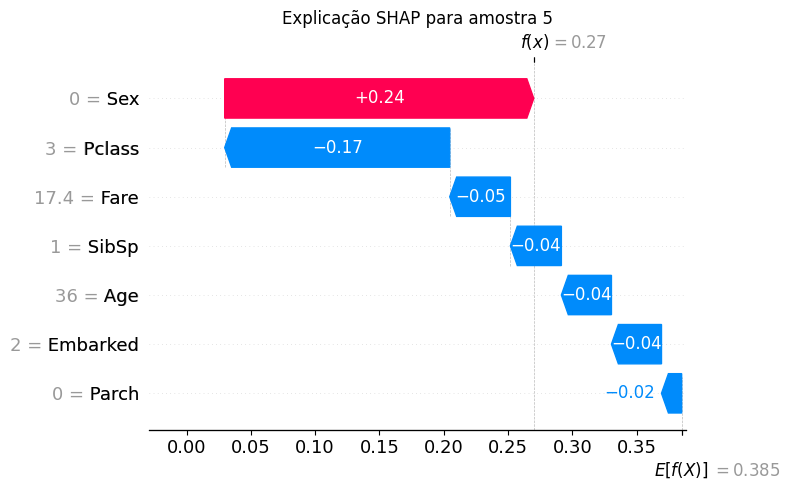


Interpretação da explicação individual:
- As setas vermelhas (positivas) contribuem para aumentar a chance de sobrevivência.
- As setas azuis (negativas) contribuem para diminuir a chance.
- O valor base é a probabilidade média de sobrevivência (em log-odds).
- O valor final é a previsão para esta amostra.

Análise detalhada da amostra:
  - Pclass (valor 3.00) contribuiu negativamente com -0.1750
  - Sex (valor 0.00) contribuiu positivamente com 0.2403

FIM DA ATIVIDADE


In [99]:
# =============================================================================
# 7. Explicação de uma previsão individual
# =============================================================================
print("\n" + "="*60)
print("7. EXPLICAÇÃO INDIVIDUAL")
print("="*60)

# Escolher um índice do conjunto de teste
indice = 5
amostra = X_test.iloc[indice:indice+1]
valor_real = y_test.iloc[indice]
pred = model.predict(amostra)[0]
prob = model.predict_proba(amostra)[0]

print(f"\nAmostra índice {indice} no conjunto de teste:")
print("Valores das features:")
print(amostra.T)
print(f"\nValor real: {'Sobreviveu' if valor_real == 1 else 'Não Sobreviveu'}")
print(f"Previsão do modelo: {'Sobreviveu' if pred == 1 else 'Não Sobreviveu'}")
print(f"Probabilidades: Não Sobreviveu: {prob[0]:.4f}, Sobreviveu: {prob[1]:.4f}")

# Explicação SHAP para essa amostra
# Corrigido: `shap_values` é (n_samples, n_features, n_classes)
# Queremos todas as features para a amostra 'indice' e para a classe de sobrevivência (index 1)
shap_individual = shap_values[indice, :, 1]

plt.figure(figsize=(10,5))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_individual,
        base_values=explainer.expected_value[1],
        data=amostra.iloc[0],
        feature_names=feature_names.tolist()
    ),
    show=False
)
plt.title(f'Explicação SHAP para amostra {indice}')
plt.tight_layout()
plt.show()

print("\nInterpretação da explicação individual:")
print("- As setas vermelhas (positivas) contribuem para aumentar a chance de sobrevivência.")
print("- As setas azuis (negativas) contribuem para diminuir a chance.")
print("- O valor base é a probabilidade média de sobrevivência (em log-odds).")
print("- O valor final é a previsão para esta amostra.")

# Exemplo de análise textual:
print("\nAnálise detalhada da amostra:")
for i, feat in enumerate(feature_names):
    # Verifica se o índice 'i' é válido para shap_individual
    if i < len(shap_individual) and abs(shap_individual[i]) > 0.05:
        sinal = "positivamente" if shap_individual[i] > 0 else "negativamente"
        print(f"  - {feat} (valor {amostra.iloc[0][feat]:.2f}) contribuiu {sinal} com {shap_individual[i]:.4f}")

print("\n" + "="*60)
print("FIM DA ATIVIDADE")
print("="*60)